In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Assignments/Sentiment Analysis/nlp_dataset.csv")
df

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear
...,...,...
5932,i begun to feel distressed for you,fear
5933,i left feeling annoyed and angry thinking that...,anger
5934,i were to ever get married i d have everything...,joy
5935,i feel reluctant in applying there because i w...,fear


In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Cleaning

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation/numbers
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['Comment'].apply(clean_text)


In [6]:
# 2. Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['Emotion']

# 3. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [7]:
# 4. Model Development
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

# 5. Model Comparison
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    print(f"{name} Results:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(classification_report(y_true, y_pred))
    print("-"*50)

evaluate_model("Naive Bayes", y_test, nb_preds)
evaluate_model("SVM", y_test, svm_preds)


Naive Bayes Results:
Accuracy: 0.8897
F1-score: 0.8897
              precision    recall  f1-score   support

       anger       0.88      0.91      0.89       400
        fear       0.88      0.90      0.89       388
         joy       0.92      0.86      0.89       400

    accuracy                           0.89      1188
   macro avg       0.89      0.89      0.89      1188
weighted avg       0.89      0.89      0.89      1188

--------------------------------------------------
SVM Results:
Accuracy: 0.9377
F1-score: 0.9377
              precision    recall  f1-score   support

       anger       0.94      0.93      0.94       400
        fear       0.94      0.93      0.93       388
         joy       0.93      0.95      0.94       400

    accuracy                           0.94      1188
   macro avg       0.94      0.94      0.94      1188
weighted avg       0.94      0.94      0.94      1188

--------------------------------------------------


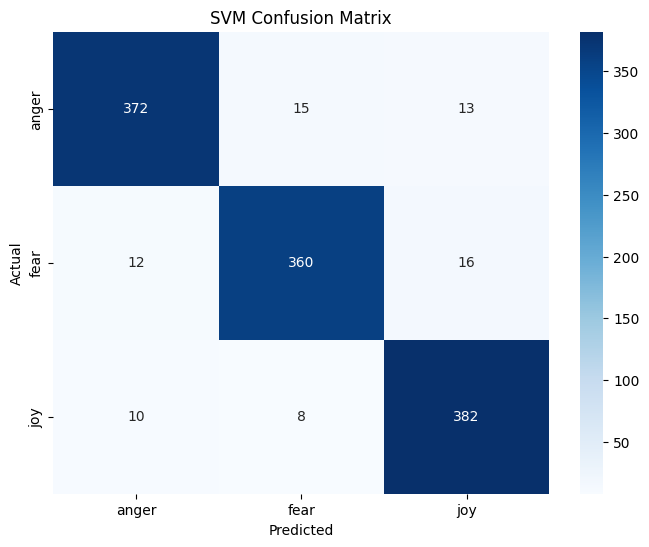

In [8]:
# Confusion Matrix for SVM
cm = confusion_matrix(y_test, svm_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
